# Testing different activation functions and depths of neural network

In [19]:
from source.runge_preprocessing import y_train, x_train_scaled, ETA_VALUES, LAMBDA_VALUES, RUNGE_MAX_ITERATIONS, MOMENTUM, VERBOSE, RUNGE_MAX_ITERATIONS, x_train_scaled, y_train, x_test, y_test, x, y
import source.activation_functions as activations_functions
from source.neural_network import NN
from source.utils import neural_network_loop, create_activations_layderdim
from source.plotting import plot_runges, plot_heatmap



### Defining different activation functions and layers, and creating list and dimension to use in own FFNN code


In [20]:
# Settings for this task

ITERATIONS = 10
MOMENTUM = 0.9

VERBOSE = False
SHOW_PLOT = True
SAVE_FIGURE = True

OPTIMIZER = 'ADAM'
ACTIVATION_FUNC = 'RELU'

SAVE_FIGURE = True
SHOW_PLOT = True

RUNGE_HIDDEN = (50,100)



In [21]:
# Defining different activation functions and layers, and creating list and dimension to use in own FFNN code

# Activation output always linear with regression
ACTIVATION_FUNCTION_OUTPUT = activations_functions.linear
ACTIVATION_FUNCTION_OUTPUT_DERIVATIVE = activations_functions.linear_derivative

if ACTIVATION_FUNC=='sigmoid':
    ACTIVATION_FUNCTION = activations_functions.sigmoid
    ACTIVATION_FUNCTION_DERIVATIVE = activations_functions.sigmoid_derivative
elif ACTIVATION_FUNC=='RELU':
    ACTIVATION_FUNCTION = activations_functions.RELU
    ACTIVATION_FUNCTION_DERIVATIVE = activations_functions.RELU_derivative
elif ACTIVATION_FUNC=='LRELU':
    ACTIVATION_FUNCTION = activations_functions.LRELU
    ACTIVATION_FUNCTION_DERIVATIVE = activations_functions.LRELU_derivative

activations, activations_derivative, _dim = create_activations_layderdim(ACTIVATION_FUNCTION, ACTIVATION_FUNCTION_DERIVATIVE, ACTIVATION_FUNCTION_OUTPUT, ACTIVATION_FUNCTION_OUTPUT_DERIVATIVE, RUNGE_HIDDEN, y_train, x_train_scaled)


In [22]:

model = NN(dims = _dim, activation_funcs = activations, activation_ders = activations_derivative)
results = neural_network_loop(model, ETA_VALUES, LAMBDA_VALUES, OPTIMIZER, ITERATIONS, x_train_scaled, y_train, x_test, y_test, momentum_val=MOMENTUM, verbose=VERBOSE)

Using scheduler: ADAM with Eta=0.1
Using scheduler: ADAM with Eta=0.1
Using scheduler: ADAM with Eta=0.1
Using scheduler: ADAM with Eta=0.1
Using scheduler: ADAM with Eta=0.1
Using scheduler: ADAM with Eta=0.1
Using scheduler: ADAM with Eta=0.1
Using scheduler: ADAM with Eta=0.1
Using scheduler: ADAM with Eta=0.1
Using scheduler: ADAM with Eta=0.1
Using scheduler: ADAM with Eta=0.01
Using scheduler: ADAM with Eta=0.01
Using scheduler: ADAM with Eta=0.01
Using scheduler: ADAM with Eta=0.01
Using scheduler: ADAM with Eta=0.01
Using scheduler: ADAM with Eta=0.01
Using scheduler: ADAM with Eta=0.01
Using scheduler: ADAM with Eta=0.01
Using scheduler: ADAM with Eta=0.01
Using scheduler: ADAM with Eta=0.01
Using scheduler: ADAM with Eta=0.001
Using scheduler: ADAM with Eta=0.001
Using scheduler: ADAM with Eta=0.001
Using scheduler: ADAM with Eta=0.001
Using scheduler: ADAM with Eta=0.001
Using scheduler: ADAM with Eta=0.001
Using scheduler: ADAM with Eta=0.001
Using scheduler: ADAM with Eta=

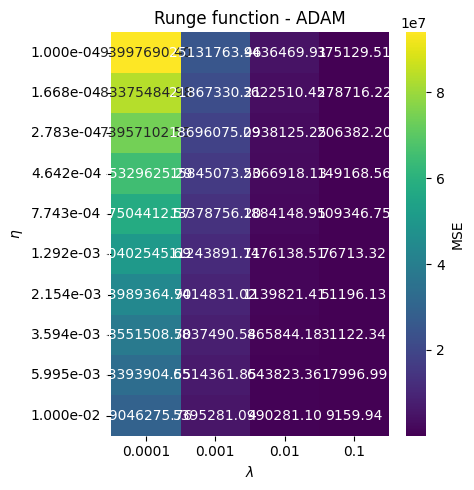

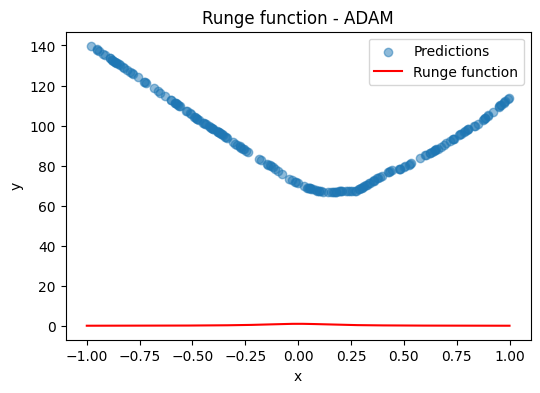

In [ ]:
# Plotting

plot_heatmap(results, title=f'Runge function - {OPTIMIZER}', heat_metric='MSE', filename=f'part_d-heatmap_{RUNGE_HIDDEN}_{OPTIMIZER}_afunc{ACTIVATION_FUNC}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)

# Print best MSE 
min_row = results.loc[results['MSE'].idxmin()]
predictions = results.loc[results['MSE'].idxmin(), 'Predictions']
plot_runges(x, y, x_test, predictions, title=f'Runge function - {OPTIMIZER}',filename=f'part_d-heatmap_{RUNGE_HIDDEN}_{OPTIMIZER}_afunc{ACTIVATION_FUNC}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)